# Interpreting Logically Constrained Solutions

This notebook focuses on **reading and explaining** solutions from models that contain logical constraints.

You will learn to:
- Distinguish between decisions that were **freely chosen** by the optimizer vs. decisions that were **forced** by constraints.
- Trace a recommendation back to the **policy or constraint** that caused it.
- Communicate these explanations in plain language for stakeholders.

## Key Concepts

**Two kinds of 1s (selected decisions)**
- **Freely chosen**: selected because it improves the objective.
- **Constraint-required**: selected because a logical rule forced it once another decision was made.

**Two kinds of 0s (unselected decisions)**
- **Rejected by objective**: not chosen because it did not help the objective enough.
- **Blocked by constraint**: would have helped the objective, but a rule prevented it.

**Critical insight**: Interpreting a solution means knowing **why** each key 0 or 1 is there – objective vs. constraint – and being able to explain that in policy language.

## Step 1: Install Required Packages

### Setup: Install Required Packages

We will reuse the PuLP optimization library and supporting tools.

**What this code does:** Installs `pulp`, `pandas`, `numpy`, and `matplotlib`.

**What to look for in the output:** "Requirement already satisfied" messages or installation logs.

In [1]:
# Install required packages (needed in Google Colab; can be skipped locally if already installed)
%pip install pulp pandas numpy matplotlib -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2: Import Libraries

### Setup: Import Libraries

**What this code does:** Imports `pandas`, `numpy`, `matplotlib`, and `pulp`.

**What to look for in the output:** No output is expected; errors indicate a missing package.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpMaximize, LpStatus, lpSum, PULP_CBC_CMD

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## Step 3: Scenario – Core Projects and Supporting Projects

You are selecting a portfolio of projects. Some **supporting projects** are only needed because certain **core projects** are selected.

**Projects**:
- Core: `Core_A`, `Core_B`
- Supporting: `Support_for_A`, `Support_for_B`

Each project has:
- A **benefit** score.
- A **cost**.

**Policies**:
1. If `Core_A` is selected, `Support_for_A` **must** also be selected.
2. If `Core_B` is selected, `Support_for_B` **must** also be selected.

We will:
- Build a model that maximizes benefit under a budget, respecting these policies.
- Tag each selected project as **free** (chosen by objective) or **forced** (required by a policy).
- Explain the solution in plain language.

In [3]:
# Define project data
projects = pd.DataFrame(
    [
        {"project": "Core_A", "type": "Core", "cost": 100, "benefit": 220},
        {"project": "Core_B", "type": "Core", "cost": 110, "benefit": 210},
        {"project": "Support_for_A", "type": "Support", "cost": 40, "benefit": 70},
        {"project": "Support_for_B", "type": "Support", "cost": 35, "benefit": 60},
    ]
)

budget = 220

print("PROJECT DATA:")
print(projects.to_string(index=False))
print("\nBudget:", budget)
print("Policies:")
print("  If Core_A is selected, Support_for_A must be selected.")
print("  If Core_B is selected, Support_for_B must be selected.")

PROJECT DATA:
      project    type  cost  benefit
       Core_A    Core   100      220
       Core_B    Core   110      210
Support_for_A Support    40       70
Support_for_B Support    35       60

Budget: 220
Policies:
  If Core_A is selected, Support_for_A must be selected.
  If Core_B is selected, Support_for_B must be selected.


## Step 4: Build the Logically Constrained Portfolio Model

**Decision variables**:
- `x[p]` = 1 if project `p` is selected, 0 otherwise.

**Constraints**:
- Budget: total cost ≤ budget.
- IF-THEN rules:
  - `x[Support_for_A] ≥ x[Core_A]`
  - `x[Support_for_B] ≥ x[Core_B]`

**Objective**:
- Maximize total benefit.

We will also record simple **metadata** about which constraints can force each supporting project, so we can tag decisions later.

In [4]:
# Build the optimization model

model = LpProblem("Core_Support_Interpretation", LpMaximize)

# Decision variables
x = {
    row["project"]: LpVariable(f"x_{row['project']}", lowBound=0, upBound=1, cat="Binary")
    for _, row in projects.iterrows()
}

# Objective: maximize total benefit
model += lpSum(projects.apply(lambda r: r["benefit"] * x[r["project"]], axis=1)), "Total_Benefit"

# Budget constraint
model += lpSum(projects.apply(lambda r: r["cost"] * x[r["project"]], axis=1)) <= budget, "Budget_Limit"

# Logical constraints: support projects required by core projects
constraint_metadata = []

c1 = model.addConstraint(x["Support_for_A"] >= x["Core_A"], name="Core_A_requires_Support_for_A")
constraint_metadata.append(
    {
        "constraint_name": "Core_A_requires_Support_for_A",
        "forced_project": "Support_for_A",
        "trigger_project": "Core_A",
    }
)

c2 = model.addConstraint(x["Support_for_B"] >= x["Core_B"], name="Core_B_requires_Support_for_B")
constraint_metadata.append(
    {
        "constraint_name": "Core_B_requires_Support_for_B",
        "forced_project": "Support_for_B",
        "trigger_project": "Core_B",
    }
)

solver = PULP_CBC_CMD(msg=False)
model.solve(solver)

status = LpStatus[model.status]
print("Model status:", status)

solution = []
for _, row in projects.iterrows():
    p = row["project"]
    solution.append(
        {
            "project": p,
            "type": row["type"],
            "cost": row["cost"],
            "benefit": row["benefit"],
            "x (selected 0/1)": int(x[p].value()),
        }
    )

sol_df = pd.DataFrame(solution)
sol_df["cost_if_selected"] = sol_df["x (selected 0/1)"] * sol_df["cost"]
sol_df["benefit_if_selected"] = sol_df["x (selected 0/1)"] * sol_df["benefit"]

print("\nSOLUTION (before interpretation tags):")
print(sol_df.to_string(index=False))
print("\nTotal cost:", int(sol_df["cost_if_selected"].sum()))
print("Total benefit:", int(sol_df["benefit_if_selected"].sum()))

Model status: Optimal

SOLUTION (before interpretation tags):
      project    type  cost  benefit  x (selected 0/1)  cost_if_selected  benefit_if_selected
       Core_A    Core   100      220                 1               100                  220
       Core_B    Core   110      210                 0                 0                    0
Support_for_A Support    40       70                 1                40                   70
Support_for_B Support    35       60                 1                35                   60

Total cost: 175
Total benefit: 350


## Step 5: Tagging Decisions as Free vs Forced

We now build an interpretation table that adds two columns:
- `role`: "free" or "forced by constraint".
- `explanation`: short text describing **why** the project is selected or not.

**Simple interpretation rules for this example**:
- For each supporting project that is 1 (selected):
  - If its corresponding core project is also 1, tag it as **forced** by the relevant constraint.
- For each core project that is 1:
  - Tag as **free** – the optimizer chose it for benefit relative to cost.
- For unselected projects (0):
  - Tag as **not selected** due to budget/objective (we do not distinguish blocked vs rejected in this small example).

This gives you a concrete demonstration of how logical rules create **forced** selections.

In [5]:
# Tag each project as free vs forced based on the simple rules above

role = []
explanation = []

selected_core = {
    "Core_A": int(x["Core_A"].value()),
    "Core_B": int(x["Core_B"].value()),
}
selected_support = {
    "Support_for_A": int(x["Support_for_A"].value()),
    "Support_for_B": int(x["Support_for_B"].value()),
}

for _, row in sol_df.iterrows():
    p = row["project"]
    selected = row["x (selected 0/1)"]

    if selected == 1 and row["type"] == "Support":
        # Check which core triggers this support
        if p == "Support_for_A" and selected_core["Core_A"] == 1:
            role.append("forced by constraint")
            explanation.append("Required because Core_A is selected (policy: Core_A => Support_for_A).")
        elif p == "Support_for_B" and selected_core["Core_B"] == 1:
            role.append("forced by constraint")
            explanation.append("Required because Core_B is selected (policy: Core_B => Support_for_B).")
        else:
            role.append("free")
            explanation.append("Selected even though no core project forces it.")
    elif selected == 1 and row["type"] == "Core":
        role.append("free")
        explanation.append("Core project selected for benefit relative to cost; it triggers support if needed.")
    else:
        role.append("not selected")
        explanation.append("Not selected under the budget and benefit tradeoff.")

sol_df["role"] = role
sol_df["explanation"] = explanation

print("INTERPRETATION TABLE:")
print(sol_df.to_string(index=False))

INTERPRETATION TABLE:
      project    type  cost  benefit  x (selected 0/1)  cost_if_selected  benefit_if_selected                 role                                                                        explanation
       Core_A    Core   100      220                 1               100                  220                 free Core project selected for benefit relative to cost; it triggers support if needed.
       Core_B    Core   110      210                 0                 0                    0         not selected                                Not selected under the budget and benefit tradeoff.
Support_for_A Support    40       70                 1                40                   70 forced by constraint             Required because Core_A is selected (policy: Core_A => Support_for_A).
Support_for_B Support    35       60                 1                35                   60                 free                                    Selected even though no core project

## Step 6: Simple Visual – Core vs Support Roles

A small bar chart can highlight how many projects of each **role** are in the solution.

**What this code does:**
- Counts how many projects are tagged as `free`, `forced by constraint`, and `not selected`.
- Plots these counts in a single, readable bar chart.

**What to look for in the output:**
- At least one supporting project should appear as **forced by constraint**, illustrating the effect of logical rules.

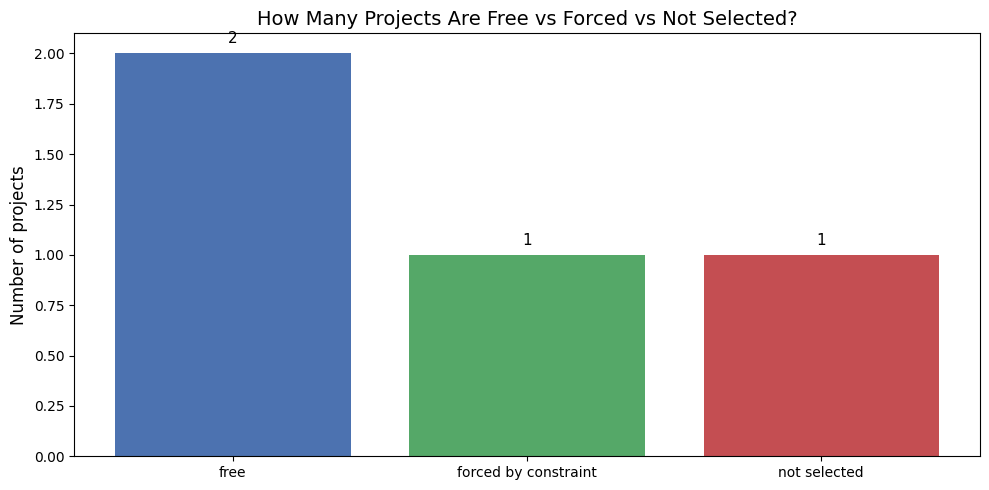

In [6]:
# Bar chart of roles

role_counts = sol_df["role"].value_counts().reindex([
    "free",
    "forced by constraint",
    "not selected",
], fill_value=0)

fig, ax = plt.subplots()

bars = ax.bar(role_counts.index, role_counts.values, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("How Many Projects Are Free vs Forced vs Not Selected?")
ax.set_ylabel("Number of projects")

for bar, count in zip(bars, role_counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.05, str(int(count)), ha="center", fontsize=11)

plt.tight_layout()
plt.show()

## Conclusion: Explaining Recommendations with Logic

In this notebook, you saw that:

- Some selected projects are **free choices** driven by the objective; others are **forced** by logical rules.
- Supporting projects can be present **only** because a policy says "if Core_X is selected, then Support_for_X must be selected".
- Tagging decisions as free vs forced helps you explain recommendations to stakeholders:
  - "We included Support_for_A because you required that whenever Core_A is funded."
- Clear explanations build trust in the model and make logical constraints visible in everyday language.